# PEFT 调包实现

快速调包的基本就是创建一个config，然后用config 和 原模型直接创建一个新的

In [2]:
import os
import torch

from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    DataCollatorForSeq2Seq,
    TrainingArguments,
    Trainer,
)

from peft import (
    PromptTuningConfig,
    PromptTuningInit,
    PromptEncoderConfig,
    PromptEncoderReparameterizationType,
    PrefixTuningConfig,
    LoraConfig,
    IA3Config,
    TaskType,
    get_peft_model,
)

## 2. 选择微调方式

只改 `PEFT_METHOD` 就行。比如想跑 P-Tuning，就改成 `p_tuning`；想跑 LoRA，就改成 `lora`。

In [3]:
# 可选：bitfit / prompt_tuning / p_tuning / prefix_tuning / lora / ia3
PEFT_METHOD = "p_tuning"

MODEL_NAME_OR_PATH = "./models/bloom-1b4-zh"
DATASET_PATH = "./data/alpaca_data_zh"
OUTPUT_ROOT = "./output"

MAX_LENGTH = 256
NUM_TRAIN_EPOCHS = 1
PER_DEVICE_TRAIN_BATCH_SIZE = 1
GRADIENT_ACCUMULATION_STEPS = 8
LOGGING_STEPS = 10
SAVE_STEPS = 20

assert PEFT_METHOD in {
    "bitfit",
    "prompt_tuning",
    "p_tuning",
    "prefix_tuning",
    "lora",
    "ia3",
}

OUTPUT_DIR = os.path.join(OUTPUT_ROOT, PEFT_METHOD)
OUTPUT_DIR

'./output\\p_tuning'

## 3. 加载数据和 tokenizer

In [4]:
ds = Dataset.load_from_disk(DATASET_PATH)
ds

Dataset({
    features: ['output', 'input', 'instruction'],
    num_rows: 26858
})

In [5]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME_OR_PATH)
tokenizer

TokenizersBackend(name_or_path='./models/bloom-1b4-zh', vocab_size=46145, model_max_length=1000000000000000019884624838656, padding_side='left', truncation_side='right', special_tokens={'bos_token': '<s>', 'eos_token': '</s>', 'unk_token': '<unk>', 'pad_token': '<pad>'}, added_tokens_decoder={
	0: AddedToken("<unk>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	1: AddedToken("<s>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	2: AddedToken("</s>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	3: AddedToken("<pad>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
})

## 4. 数据预处理



input ids: `Human: instruction + input -> Assistant: output`。

`labels` 里 prompt 部分填 `-100`，表示只在回答部分计算 loss。

Attention mask 中 Prompt 部分 填写 1, 模型需要计算关于prompt部分的一个梯度

In [7]:
def build_prompt(instruction, input_text=""):
    user_part = "\n".join(["Human: " + instruction, input_text]).strip()
    return user_part + "\n\nAssistant: "


def process_func(example):
    instruction = tokenizer(build_prompt(example["instruction"], example["input"]))
    response = tokenizer(example["output"] + tokenizer.eos_token)


    # 这里labels中的指令部分是要设置为负-100的，因为我不需要模型去预测指令部分的数据
    input_ids = instruction["input_ids"] + response["input_ids"]
    attention_mask = instruction["attention_mask"] + response["attention_mask"]
    labels = [-100] * len(instruction["input_ids"]) + response["input_ids"]

    if len(input_ids) > MAX_LENGTH:
        input_ids = input_ids[:MAX_LENGTH]
        attention_mask = attention_mask[:MAX_LENGTH]
        labels = labels[:MAX_LENGTH]

    return {
        "input_ids": input_ids,
        "attention_mask": attention_mask,
        "labels": labels,
    }


tokenized_ds = ds.map(process_func, remove_columns=ds.column_names)
tokenized_ds

Map:   0%|          | 0/26858 [00:00<?, ? examples/s]

Dataset({
    features: ['input_ids', 'attention_mask', 'labels'],
    num_rows: 26858
})

In [8]:
# 看一条输入和一条真正参与 loss 的输出，确认数据格式没错。
print(tokenizer.decode(tokenized_ds[1]["input_ids"]))
print("-" * 80)
print(tokenizer.decode([x for x in tokenized_ds[1]["labels"] if x != -100]))

Human: 解释为什么以下分数等同于1/4
输入：4/16

Assistant: 4/16等于1/4是因为我们可以约分分子分母都除以他们的最大公约数4，得到（4÷4）/ (16÷4）=1/4。分数的约分是用分子和分母除以相同的非零整数，来表示分数的一个相同的值，这因为分数实际上表示了分子除以分母，所以即使两个数同时除以同一个非零整数，分数的值也不会改变。所以4/16 和1/4是两种不同的书写形式，但它们的值相等。</s>
--------------------------------------------------------------------------------
4/16等于1/4是因为我们可以约分分子分母都除以他们的最大公约数4，得到（4÷4）/ (16÷4）=1/4。分数的约分是用分子和分母除以相同的非零整数，来表示分数的一个相同的值，这因为分数实际上表示了分子除以分母，所以即使两个数同时除以同一个非零整数，分数的值也不会改变。所以4/16 和1/4是两种不同的书写形式，但它们的值相等。</s>


## 5. 加载基础模型

这里加载的是已经预训练好的基础模型。后面只有中间的 PEFT 改造方式不同。

In [9]:
model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME_OR_PATH,
    low_cpu_mem_usage=True,
)

total_params = sum(p.numel() for p in model.parameters())
total_params

Loading weights:   0%|          | 0/294 [00:00<?, ?it/s]

1303111680

## 6. 统一的 PEFT 改造函数

这是这个 notebook 的核心：前后流程都不动，只在这里按 `PEFT_METHOD` 分支。

In [ ]:
def apply_bitfit(model):
    """BitFit：冻结所有非 bias 参数，只训练 bias。"""
    trainable_params = 0
    for name, param in model.named_parameters():
        if "bias" in name:
            param.requires_grad = True
            trainable_params += param.numel()
        else:
            param.requires_grad = False
    print(f"BitFit trainable params: {trainable_params:,}")
    return model


def build_peft_config(method):
    
    # prompt tunning 是加入一段虚拟的提示词，然后这个提示词是已经有的
    # 然后模型是直接训练虚构的Embedding层参数
    if method == "prompt_tuning":
        init_text = "下面是一段人与机器人的对话。"
        return PromptTuningConfig(
            task_type=TaskType.CAUSAL_LM,
            prompt_tuning_init=PromptTuningInit.TEXT,
            prompt_tuning_init_text=init_text,
            num_virtual_tokens=len(tokenizer(init_text)["input_ids"]),
            tokenizer_name_or_path=MODEL_NAME_OR_PATH,
        )

    # P-tunning 也是加入虚构的提示词，
    # 1. 这部分提示词会经过嵌入层进行向量化
    # 2. 然后再加入到incodeder层进行重新参数化， MLP都有可能
    # 3. 这部分虚拟的input 会和其他部分进行contact
    if method == "p_tuning":
        return PromptEncoderConfig(
            task_type=TaskType.CAUSAL_LM,
            num_virtual_tokens=10, # 虚拟token数量
            encoder_reparameterization_type=PromptEncoderReparameterizationType.MLP, # 指定encoder层网络的样子
            
            # 下面的参数都用来定义encoder层的参数
            encoder_dropout=0.1, 
            encoder_num_layers=5,
            encoder_hidden_size=1024,
        )
    
    if method == "prefix_tuning":
        return PrefixTuningConfig(
            task_type=TaskType.CAUSAL_LM,
            num_virtual_tokens=10,
            prefix_projection=True,
        )

    if method == "lora":
        return LoraConfig(
            task_type=TaskType.CAUSAL_LM,
            r=8,
            lora_alpha=32,
            lora_dropout=0.05,
            # BLOOM 的 attention 融合 QKV 线性层通常叫 query_key_value。
            # 如果换成 LLaMA/Qwen，常改成 ["q_proj", "v_proj"] 或 ["q_proj", "k_proj", "v_proj", "o_proj"]。
            target_modules=["query_key_value"],
            modules_to_save=["word_embeddings"],
        )

    if method == "ia3":
        return IA3Config(task_type=TaskType.CAUSAL_LM)

    raise ValueError(f"Unsupported method: {method}")


def apply_peft_method(model, method):
    if method == "bitfit":
        return apply_bitfit(model)

    config = build_peft_config(method)
    print(config)
    peft_model = get_peft_model(model, config)
    peft_model.print_trainable_parameters()
    return peft_model


model = apply_peft_method(model, PEFT_METHOD)
model

# 伪代码（原理）

## Prompt-Tunning

在输入 embedding 前面拼一段可训练向量。

```

# 原始输入
input_ids = tokenizer(text)["input_ids"]
# shape: [batch_size, seq_len]

# 原始文本 token embedding
token_embedding = base_model.get_input_embeddings()(input_ids)
# shape: [batch_size, seq_len, hidden_size]

# 直接创建可训练 soft prompt
soft_prompt = nn.Parameter(
    torch.randn(num_virtual_tokens, hidden_size)
)
# shape: [num_virtual_tokens, hidden_size]

# 扩展到 batch
soft_prompt = soft_prompt.unsqueeze(0).expand(batch_size, -1, -1)
# shape: [batch_size, num_virtual_tokens, hidden_size]

# 拼到原始输入前面
inputs_embeds = torch.cat(
    [soft_prompt, token_embedding],
    dim=1
)
# shape: [batch_size, num_virtual_tokens + seq_len, hidden_size]

# prompt 要被模型看到
prompt_attention_mask = torch.ones(batch_size, num_virtual_tokens)

attention_mask = torch.cat(
    [prompt_attention_mask, attention_mask],
    dim=1
)

# prompt 不参与 loss
prompt_labels = torch.full(
    (batch_size, num_virtual_tokens),
    -100
)

labels = torch.cat(
    [prompt_labels, labels],
    dim=1
)

# 喂给冻结的 base model
output = base_model(
    inputs_embeds=inputs_embeds,
    attention_mask=attention_mask,
    labels=labels
)

loss = output.loss
loss.backward()

# 只更新 soft_prompt
optimizer.step()


```

## P-Tunning 

也是在输入 embedding 前面拼 soft prompt

但 soft prompt 不是直接裸训，而是由 PromptEncoder 生成。

```

# 原始输入
input_ids = tokenizer(text)["input_ids"]
# shape: [batch_size, seq_len]

# 原始文本 token embedding
token_embedding = base_model.get_input_embeddings()(input_ids)
# shape: [batch_size, seq_len, hidden_size]

# 构造虚拟 token id
virtual_token_ids = torch.arange(num_virtual_tokens)
# shape: [num_virtual_tokens]

virtual_token_ids = virtual_token_ids.unsqueeze(0).expand(batch_size, -1)
# shape: [batch_size, num_virtual_tokens]

# PromptEncoder 内部：
# 1. 查 virtual token embedding
# 2. 经过 MLP/LSTM 重参数化
soft_prompt = prompt_encoder(virtual_token_ids)
# shape: [batch_size, num_virtual_tokens, hidden_size]

# 拼到原始输入前面
inputs_embeds = torch.cat(
    [soft_prompt, token_embedding],
    dim=1
)

# prompt 要被模型看到
prompt_attention_mask = torch.ones(batch_size, num_virtual_tokens)

attention_mask = torch.cat(
    [prompt_attention_mask, attention_mask],
    dim=1
)

# prompt 不参与 loss
prompt_labels = torch.full(
    (batch_size, num_virtual_tokens),
    -100
)

labels = torch.cat(
    [prompt_labels, labels],
    dim=1
)

# 喂给冻结的 base model
output = base_model(
    inputs_embeds=inputs_embeds,
    attention_mask=attention_mask,
    labels=labels
)

loss = output.loss
loss.backward()

# 只更新 PromptEncoder
optimizer.step()


```

PromptEncoder 如下结构 ： 是一个embedding层，然后再加上一个MLP
```
class PromptEncoder(nn.Module):
    def __init__(self):
        self.embedding = nn.Embedding(num_virtual_tokens, hidden_size)
        self.mlp = nn.Sequential(
            nn.Linear(hidden_size, encoder_hidden_size),
            nn.Tanh(),
            nn.Linear(encoder_hidden_size, hidden_size),
        )

    def forward(self, virtual_token_ids):
        x = self.embedding(virtual_token_ids)
        soft_prompt = self.mlp(x)
        return soft_prompt
```

## Prefix-Tunning

不是把 soft prompt 拼到输入 embedding 前面

而是给每一层 Transformer attention 的 K/V 前面拼 prefix_K 和 prefix_V。

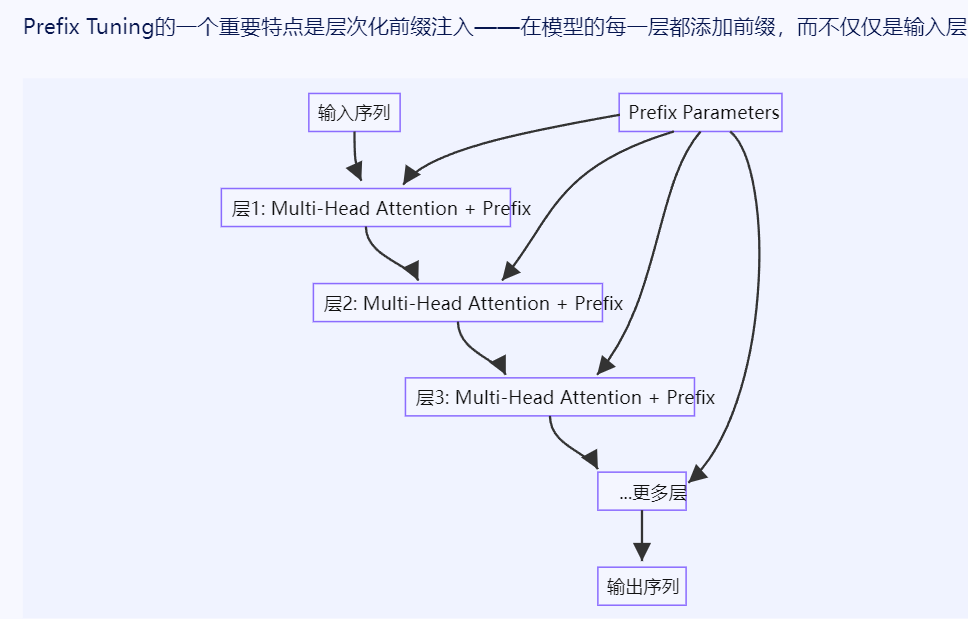

标准 Transformer 注意力大致是：

```python
attention_scores = query @ key.transpose(-2, -1)
attention_weights = softmax(attention_scores / sqrt(key_dim))
output = attention_weights @ value
```

Prefix Tuning 后：

```python
extended_key = concat(prefix_key, key)
extended_value = concat(prefix_value, value)

attention_scores = query @ extended_key.transpose(-2, -1)
attention_weights = softmax(attention_scores / sqrt(key_dim))
output = attention_weights @ extended_value
```

In [ ]:
import torch
import torch.nn as nn


class PrefixEncoder(nn.Module):
    def __init__(
        self,
        prefix_length: int,        # 虚拟 prefix token 数量
        model_hidden_size: int,    # 模型 hidden size
        encoder_hidden_size: int,  # MLP 中间层维度
        num_layers: int,           # Transformer 层数
        num_heads: int,            # attention head 数
    ):
        super().__init__()

        self.prefix_length = prefix_length
        self.model_hidden_size = model_hidden_size
        self.encoder_hidden_size = encoder_hidden_size
        self.num_layers = num_layers
        self.num_heads = num_heads

        assert model_hidden_size % num_heads == 0
        self.head_dim = model_hidden_size // num_heads

        # PrefixEncoder 的第 1 部分：Embedding 层
        # 尺寸：参数 [prefix_length, model_hidden_size]
        # 目的：把虚拟 token id 映射成连续向量。
        self.prefix_embedding = nn.Embedding(
            prefix_length,
            model_hidden_size,
        )

        # PrefixEncoder 的第 2 部分：两层 MLP
        # 目的：把 prefix embedding 映射成所有层的 prefix key/value。
        self.prefix_mlp = nn.Sequential(
            # 尺寸：[..., model_hidden_size] -> [..., encoder_hidden_size]
            # 目的：投影到中间空间，增加可学习表达能力。
            nn.Linear(model_hidden_size, encoder_hidden_size),

            # 尺寸：不变
            # 目的：加入非线性，否则两层 Linear 近似等价于一层 Linear。
            nn.Tanh(),

            # 尺寸：[..., encoder_hidden_size]
            #      -> [..., num_layers * 2 * model_hidden_size]
            # 目的：一次性生成所有层的 prefix key/value。
            nn.Linear(
                encoder_hidden_size,
                num_layers * 2 * model_hidden_size,
            ),
        )

    def forward(self, batch_size: int, device=None):
        if device is None:
            device = self.prefix_embedding.weight.device

        # 1. 构造虚拟 prefix token id
        # 尺寸：[prefix_length]
        # 目的：生成 prefix token 编号；它们不是自然语言 token，只用于查表。
        prefix_token_ids = torch.arange(
            self.prefix_length,
            device=device,
        )

        # 2. 复制到 batch 维度
        # 尺寸：[prefix_length] -> [1, prefix_length] -> [batch_size, prefix_length]
        # 目的：batch 里的每个样本都使用同一组 prefix token。
        prefix_token_ids = prefix_token_ids.unsqueeze(0).expand(
            batch_size,
            -1,
        )

        # 3. 查 embedding
        # 尺寸：[batch_size, prefix_length]
        #      -> [batch_size, prefix_length, model_hidden_size]
        # 目的：把每个虚拟 token id 变成一个可训练连续向量。
        prefix_embeddings = self.prefix_embedding(prefix_token_ids)

        # 4. 经过两层 MLP
        # 尺寸：[batch_size, prefix_length, model_hidden_size]
        #      -> [batch_size, prefix_length, num_layers * 2 * model_hidden_size]
        # 目的：为每个 prefix token 生成所有 Transformer 层的 prefix key 和 prefix value。
        prefix_key_values = self.prefix_mlp(prefix_embeddings)

        # 5. 拆开 layer / key-value / head 维度
        # 尺寸：[batch_size, prefix_length, num_layers * 2 * model_hidden_size]
        #      -> [batch_size, prefix_length, num_layers, 2, num_heads, head_dim]
        # 目的：把扁平的最后一维拆成：第几层、key/value、head、head_dim。
        prefix_key_values = prefix_key_values.view(
            batch_size,
            self.prefix_length,
            self.num_layers,
            2,
            self.num_heads,
            self.head_dim,
        )

        # 6. 调整成模型常用格式
        # 尺寸：[batch_size, prefix_length, num_layers, 2, num_heads, head_dim]
        #      -> [num_layers, 2, batch_size, num_heads, prefix_length, head_dim]
        # 目的：让每一层可以直接取出自己的 prefix_key 和 prefix_value。
        prefix_key_values = prefix_key_values.permute(
            2,  # num_layers
            3,  # key/value
            0,  # batch_size
            4,  # num_heads
            1,  # prefix_length
            5,  # head_dim
        ).contiguous()

        return prefix_key_values

## Lora

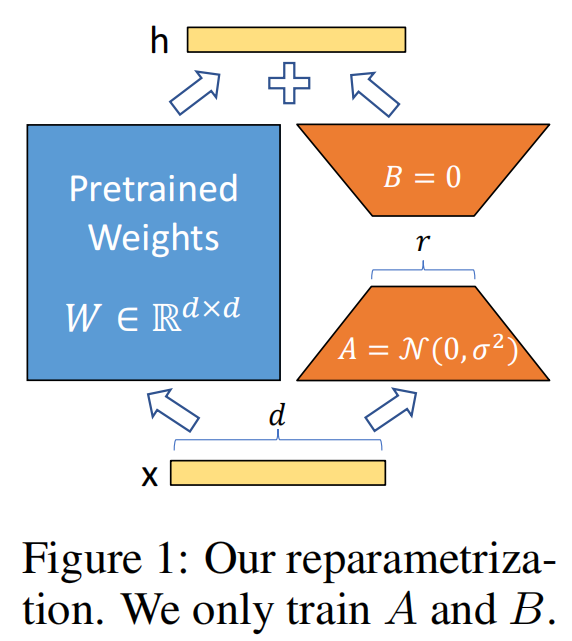

这张图很重要，因为它把 LoRA 的几个核心设计压缩到一个图里：

- 左侧蓝色块是冻结的预训练权重 $\mathbf{W}$，它仍然参与前向计算，但不参与训练更新。
- 右侧橙色路径是 LoRA adapter，只训练低秩矩阵 $\mathbf{A}$ 和 $\mathbf{B}$。
- $\mathbf{A}$ 把输入从原维度 $d$ 投影到低秩瓶颈维度 $r$，$\mathbf{B}$ 再把它投影回输出维度。
- 图中标明 $\mathbf{A} \sim \mathcal{N}(0,\sigma^2)$、$\mathbf{B}=0$，对应 LoRA 的“静默启动”初始化：初始不改变原模型输出，但训练信号可以先流向 $\mathbf{B}$。
- 输出 $h$ 来自原模型路径和 LoRA 增量路径相加，因此 LoRA 是一种并联增量结构，而不是替换原权重。

一句话：这张图说明 LoRA 的本质是 **冻结原权重 + 并联一个可训练的低秩增量分支**。


## QLora

QLora相较于Lora里面的Q是会对模型的参数进行分块，比如64个32bit的参数为一组，然后每个32bit的参数都压缩成4bit，即近似成2^4个数字的值

关键是：NF4 不是让全模型只取 16 个真实数值，而是使用：

```text
全局共享的 16 个归一化模板值
+ 每个 block 自己的缩放系数 c
+ 每个权重自己的 4bit 索引
```

对一个权重 $w$，量化过程可以理解为：

1. 选一个 block，例如 64 个权重一组。
2. 计算这个 block 的缩放系数：

$$
c = \max(|w_i|)
$$

3. 把权重归一化到 $[-1, 1]$：

$$
u = \frac{w}{c}
$$

4. 在 NF4 的 16 个 codebook 值里找最接近 $u$ 的值，只保存它的索引。
5. 反量化时恢复为：

$$
\hat{w} = c \cdot Q[index]
$$

其中 $Q$ 是 NF4 的 16 个归一化代表值。
